# Import the libraries needed for data analysis and visualization

In [1]:
import random
import pandas as pd
import numpy as np
import sklearn as skl
import matplotlib.pyplot as plt
import seaborn as sns


# Load the hotel bookings dataset into a Pandas DataFrame

In [2]:
df = pd.read_csv("hotel_bookings.csv")

In [3]:
# Check the number of rows and columns in the dataset
df.shape

(119390, 32)

In [4]:
# Display the first 5 rows to get an initial overview of the dataset
df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [5]:
df.tail(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119380,City Hotel,0,44,2017,August,35,31,1,3,2,...,No Deposit,9.0,NaN,0,Transient,140.75,0,1,Check-Out,2017-09-04
119381,City Hotel,0,188,2017,August,35,31,2,3,2,...,No Deposit,14.0,NaN,0,Transient,99.00,0,0,Check-Out,2017-09-05
119382,City Hotel,0,135,2017,August,35,30,2,4,3,...,No Deposit,7.0,NaN,0,Transient,209.00,0,0,Check-Out,2017-09-05
119383,City Hotel,0,164,2017,August,35,31,2,4,2,...,No Deposit,42.0,NaN,0,Transient,87.60,0,0,Check-Out,2017-09-06
119384,City Hotel,0,21,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,2,Check-Out,2017-09-06
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [6]:
# Display information about columns, data types, and non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [7]:
# Generate descriptive statistics for numerical columns
# to understand their distributions and identify potential issues
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [8]:
# Check how many completely duplicated rows exist in the dataset
df.duplicated().sum()

np.int64(31994)

In [9]:
# Count the number of missing values in each column
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [10]:
# Calculate the percentage of missing values in each column
# and display only columns that contain missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

company     94.306893
agent       13.686238
country      0.408744
children     0.003350
dtype: float64

# Define the target variable and check its class distribution

In [11]:
target = "is_canceled"

print("Target column:", target)
print(df[target].value_counts())
print(df[target].value_counts(normalize=True) * 100)

Target column: is_canceled
is_canceled
0    75166
1    44224
Name: count, dtype: int64
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


In [12]:
# Check the number of unique agents and companies
# and inspect their most frequent values, including missing values

print("Agent unique values:", df['agent'].nunique())
print("Company unique values:", df['company'].nunique())

print("\nTop Agent values:")
print(df['agent'].value_counts(dropna=False).head(10))

print("\nTop Company values:")
print(df['company'].value_counts(dropna=False).head(10))

Agent unique values: 333
Company unique values: 352

Top Agent values:
agent
9.0      31961
NaN      16340
240.0    13922
1.0       7191
14.0      3640
7.0       3539
6.0       3290
250.0     2870
241.0     1721
28.0      1666
Name: count, dtype: int64

Top Company values:
company
NaN      112593
40.0        927
223.0       784
67.0        267
45.0        250
153.0       215
174.0       149
219.0       141
281.0       138
154.0       133
Name: count, dtype: int64


In [13]:
# Check the distribution of the children column, including missing values

df['children'].value_counts(dropna=False)

children
0.0     110796
1.0       4861
2.0       3652
3.0         76
NaN          4
10.0         1
Name: count, dtype: int64

In [14]:
# Display the rows where the number of children is missing
# to investigate the missing values before filling them

df[df['children'].isnull()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40600,City Hotel,1,2,2015,August,32,3,1,0,2,...,No Deposit,NaN,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-01
40667,City Hotel,1,1,2015,August,32,5,0,2,2,...,No Deposit,14.0,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-04
40679,City Hotel,1,1,2015,August,32,5,0,2,3,...,No Deposit,NaN,NaN,0,Transient-Party,18.0,0,2,Canceled,2015-08-04
41160,City Hotel,1,8,2015,August,33,13,2,5,2,...,No Deposit,9.0,NaN,0,Transient-Party,76.5,0,1,Canceled,2015-08-09


In [15]:
# Count the missing values in the country column
# because the customer's country cannot be determined for these records

df['country'].isnull().sum()

np.int64(488)

In [16]:
# Check the distribution of agent IDs, including missing values
# to understand whether missing values represent bookings without an agent

df['agent'].value_counts(dropna=False).head(10)

agent
9.0      31961
NaN      16340
240.0    13922
1.0       7191
14.0      3640
7.0       3539
6.0       3290
250.0     2870
241.0     1721
28.0      1666
Name: count, dtype: int64

In [17]:
# Check the distribution of company IDs, including missing values
# to understand whether missing values represent bookings without a company

df['company'].value_counts(dropna=False).head(10)

company
NaN      112593
40.0        927
223.0       784
67.0        267
45.0        250
153.0       215
174.0       149
219.0       141
281.0       138
154.0       133
Name: count, dtype: int64

# Handling Missing Values

In [18]:
# Replace missing children values with 0
# assuming that a missing value means no children were included in the booking

df['children'] = df['children'].fillna(0)

In [19]:
# Replace missing country values with 'Unknown'
# because the customer's country cannot be determined

df['country'] = df['country'].fillna('Unknown')

In [20]:
# Replace missing agent IDs with 0
# to represent bookings that were not associated with an agent

df['agent'] = df['agent'].fillna(0)

In [21]:
# Replace missing company IDs with 0
# to represent bookings that were not associated with a company

df['company'] = df['company'].fillna(0)

In [22]:
# Cast children, agent, and company to integer type
# these represent counts/IDs and should not stay as float after filling NaNs with 0

df['children'] = df['children'].astype(int)
df['agent'] = df['agent'].astype(int)
df['company'] = df['company'].astype(int)

In [23]:
# Verify that all missing values have been handled successfully

df.isnull().sum().sort_values(ascending=False).head(10)

hotel                        0
is_canceled                  0
lead_time                    0
arrival_date_year            0
arrival_date_month           0
arrival_date_week_number     0
arrival_date_day_of_month    0
stays_in_weekend_nights      0
stays_in_week_nights         0
adults                       0
dtype: int64

# Handle Duplicate Rows

In [24]:
# Display the first 10 duplicated rows to inspect them before removal

df[df.duplicated()].head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240,0,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250,0,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250,0,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240,0,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240,0,0,Transient,109.80,0,3,Check-Out,2015-07-08
219,Resort Hotel,1,1,2015,July,28,8,0,1,2,...,No Deposit,0,110,0,Transient,104.72,0,1,Canceled,2015-07-08
256,Resort Hotel,0,91,2015,July,28,10,0,2,2,...,No Deposit,240,0,0,Transient,73.80,0,1,Check-Out,2015-07-12
261,Resort Hotel,0,30,2015,July,28,10,2,2,2,...,No Deposit,0,0,0,Transient-Party,197.00,0,1,Check-Out,2015-07-14
353,Resort Hotel,0,98,2015,July,29,13,1,1,2,...,No Deposit,240,0,0,Transient-Party,82.00,0,3,Check-Out,2015-07-15
372,Resort Hotel,0,40,2015,July,29,13,1,4,2,...,No Deposit,250,0,0,Transient,120.00,0,2,Check-Out,2015-07-18


In [25]:
# Remove completely duplicated rows from the dataset

df = df.drop_duplicates()

In [26]:
# Check the dataset shape after removing duplicate rows

df.shape

(87396, 32)

In [27]:
# Verify that no completely duplicated rows remain in the dataset

df.duplicated().sum()

np.int64(0)

# Note:
# reservation_status and reservation_status_date will not be used
# as features in the cancellation prediction model because they contain
# information about the final reservation outcome and may cause data leakage.

# Check Invalid Values

In [28]:
# Check how many bookings have zero adults

(df['adults'] == 0).sum()

np.int64(385)

In [29]:
# Display bookings where the number of adults is zero

df[df['adults'] == 0].head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,...,No Deposit,0,174,0,Transient-Party,0.0,0,0,Check-Out,2015-10-06
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,...,No Deposit,0,174,0,Transient,0.0,0,0,Check-Out,2015-10-12
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,...,No Deposit,38,0,0,Transient-Party,0.0,0,0,Check-Out,2015-11-23
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,...,No Deposit,308,0,122,Transient-Party,0.0,0,0,Check-Out,2016-01-04
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,...,No Deposit,308,0,122,Transient-Party,0.0,0,0,Check-Out,2016-01-05
4127,Resort Hotel,1,0,2016,February,8,15,0,0,0,...,No Deposit,0,383,0,Transient,0.0,0,0,Canceled,2016-02-15
9376,Resort Hotel,1,0,2016,November,48,21,0,0,0,...,No Deposit,0,386,0,Group,0.0,0,0,Canceled,2016-11-21
31765,Resort Hotel,0,31,2016,December,53,27,2,8,0,...,No Deposit,0,0,0,Transient,28.0,1,0,Check-Out,2017-01-06
32029,Resort Hotel,0,4,2017,January,2,14,0,1,0,...,No Deposit,168,0,0,Transient-Party,0.0,0,0,Check-Out,2017-01-15
32827,Resort Hotel,0,46,2017,January,4,25,3,9,0,...,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2017-02-06


In [30]:
# Display bookings with zero adults to investigate whether these records are valid

df[df['adults'] == 0][
    ['adults', 'children', 'babies', 'hotel', 'is_canceled', 'customer_type']
]

,adults,children,babies,hotel,is_canceled,customer_type
2224,0,0,0,Resort Hotel,0,Transient-Party
2409,0,0,0,Resort Hotel,0,Transient
3181,0,0,0,Resort Hotel,0,Transient-Party
3684,0,0,0,Resort Hotel,0,Transient-Party
3708,0,0,0,Resort Hotel,0,Transient-Party
...,...,...,...,...,...,...
117204,0,2,0,City Hotel,0,Transient
117274,0,2,0,City Hotel,0,Transient
117303,0,2,0,City Hotel,0,Transient
117453,0,2,0,City Hotel,0,Transient


In [31]:
# Count zero-adult bookings by target class

df[df['adults'] == 0]['is_canceled'].value_counts()

is_canceled
0    288
1     97
Name: count, dtype: int64

In [32]:
# Count bookings where there are no adults but there are children or babies

zero_adults_with_dependents = df[
    (df['adults'] == 0) &
    ((df['children'] > 0) | (df['babies'] > 0))
]

print("Zero adults with children or babies:", len(zero_adults_with_dependents))

Zero adults with children or babies: 219


In [33]:
# Check the distribution of children and babies
# for bookings that have zero adults

zero_adults_with_dependents[['children', 'babies']].value_counts()

children  babies
2         0         201
3         0          11
1         0           4
2         1           3
Name: count, dtype: int64

In [34]:
# Identify bookings where no adults, children, or babies are recorded

zero_guests = df[
    (df['adults'] == 0) &
    (df['children'] == 0) &
    (df['babies'] == 0)
]

print("Bookings with zero guests:", len(zero_guests))

Bookings with zero guests: 166


In [35]:
# Remove bookings where no adults, children, or babies are recorded
# because these records do not represent a valid guest booking

df = df[
    ~(
        (df['adults'] == 0) &
        (df['children'] == 0) &
        (df['babies'] == 0)
    )
]

In [36]:
# Verify that no bookings with zero total guests remain

zero_guests = df[
    (df['adults'] == 0) &
    (df['children'] == 0) &
    (df['babies'] == 0)
]

print("Remaining zero-guest bookings:", len(zero_guests))

Remaining zero-guest bookings: 0


In [37]:
# Check the cancellation distribution for bookings with zero adults
# to understand how these records are distributed across the target

print(
    zero_adults_with_dependents['is_canceled']
    .value_counts()
)

print("\nCancellation percentage:")
print(
    zero_adults_with_dependents['is_canceled']
    .value_counts(normalize=True) * 100
)

is_canceled
0    138
1     81
Name: count, dtype: int64

Cancellation percentage:
is_canceled
0    63.013699
1    36.986301
Name: proportion, dtype: float64


# Check Negative ADR

In [38]:
# Check how many bookings have a negative ADR value

(df['adr'] < 0).sum()

np.int64(1)

In [39]:
# Display bookings with a negative ADR value

df[df['adr'] < 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,...,No Deposit,273,0,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


In [40]:
# Remove bookings with negative ADR values
# A negative Average Daily Rate is not logically valid

df = df[df['adr'] >= 0]

In [41]:
# Verify that no negative ADR values remain in the dataset

print("Negative ADR values:", (df['adr'] < 0).sum())

Negative ADR values: 0


# Check Negative Values

In [42]:
# Check for negative values in columns where negative values are not logically valid

non_negative_columns = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

for col in non_negative_columns:
    negative_count = (df[col] < 0).sum()
    print(f"{col}: {negative_count} negative values")

lead_time: 0 negative values
stays_in_weekend_nights: 0 negative values
stays_in_week_nights: 0 negative values
adults: 0 negative values
children: 0 negative values
babies: 0 negative values
previous_cancellations: 0 negative values
previous_bookings_not_canceled: 0 negative values
booking_changes: 0 negative values
days_in_waiting_list: 0 negative values
required_car_parking_spaces: 0 negative values
total_of_special_requests: 0 negative values


# Check Categorical Values

In [43]:
# Check the unique values and their frequencies in the hotel column

print(df['hotel'].unique())
print("\nValue counts:")
print(df['hotel'].value_counts())

<StringArray>
['Resort Hotel', 'City Hotel']
Length: 2, dtype: str

Value counts:
hotel
City Hotel      53274
Resort Hotel    33955
Name: count, dtype: int64


In [44]:
# Check the unique values and their frequencies in the meal column

print(df['meal'].unique())
print("\nValue counts:")
print(df['meal'].value_counts())

<StringArray>
['BB', 'FB', 'HB', 'SC', 'Undefined']
Length: 5, dtype: str

Value counts:
meal
BB           67906
SC            9391
HB            9080
Undefined      492
FB             360
Name: count, dtype: int64


In [45]:
# Check the unique values and their frequencies in the deposit_type column

print(df['deposit_type'].unique())
print("\nValue counts:")
print(df['deposit_type'].value_counts())

<StringArray>
['No Deposit', 'Refundable', 'Non Refund']
Length: 3, dtype: str

Value counts:
deposit_type
No Deposit    86084
Non Refund     1038
Refundable      107
Name: count, dtype: int64


In [46]:
# Check unique values and frequencies in the market_segment column

print(df['market_segment'].unique())

print("\nValue counts:")
print(df['market_segment'].value_counts())

<StringArray>
[       'Direct',     'Corporate',     'Online TA', 'Offline TA/TO',
 'Complementary',        'Groups',     'Undefined',      'Aviation']
Length: 8, dtype: str

Value counts:
market_segment
Online TA        51553
Offline TA/TO    13855
Direct           11780
Groups            4921
Corporate         4200
Complementary      692
Aviation           226
Undefined            2
Name: count, dtype: int64


In [47]:
# Check unique values and frequencies in the distribution_channel column

print(df['distribution_channel'].unique())

print("\nValue counts:")
print(df['distribution_channel'].value_counts())

<StringArray>
['Direct', 'Corporate', 'TA/TO', 'Undefined', 'GDS']
Length: 5, dtype: str

Value counts:
distribution_channel
TA/TO        69028
Direct       12953
Corporate     5062
GDS            181
Undefined        5
Name: count, dtype: int64


In [48]:
# Check unique values and frequencies in the customer_type column

print(df['customer_type'].unique())

print("\nValue counts:")
print(df['customer_type'].value_counts())

<StringArray>
['Transient', 'Contract', 'Transient-Party', 'Group']
Length: 4, dtype: str

Value counts:
customer_type
Transient          71862
Transient-Party    11691
Contract            3135
Group                541
Name: count, dtype: int64


In [49]:
# Check the years available in the dataset

print(df['arrival_date_year'].unique())
print(df['arrival_date_year'].value_counts())

[2015 2016 2017]
arrival_date_year
2016    42313
2017    31632
2015    13284
Name: count, dtype: int64


In [50]:
# Check the months available in the dataset

print(df['arrival_date_month'].unique())
print(df['arrival_date_month'].value_counts())

<StringArray>
[     'July',    'August', 'September',   'October',  'November',  'December',
   'January',  'February',     'March',     'April',       'May',      'June']
Length: 12, dtype: str


arrival_date_month
August       11242
July         10043
May           8344
April         7900
June          7756
March         7488
October       6921
September     6682
February      6083
December      5112
November      4973
January       4685
Name: count, dtype: int64

In [51]:
# Check the range of arrival week numbers

print("Minimum week number:", df['arrival_date_week_number'].min())
print("Maximum week number:", df['arrival_date_week_number'].max())

Minimum week number: 1
Maximum week number: 53


In [52]:
# Check the range of arrival days within a month

print("Minimum day:", df['arrival_date_day_of_month'].min())
print("Maximum day:", df['arrival_date_day_of_month'].max())

Minimum day: 1
Maximum day: 31


In [53]:
# Convert reservation_status_date from object to datetime format

df['reservation_status_date'] = pd.to_datetime(
    df['reservation_status_date']
)

In [54]:
# Verify that reservation_status_date has been converted to datetime

df['reservation_status_date'].dtype

dtype('<M8[us]')

In [55]:
# Display the data types of all columns after the cleaning steps

df.dtypes

hotel                                        str
is_canceled                                int64
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                           str
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                   int64
babies                                     int64
meal                                         str
country                                      str
market_segment                               str
distribution_channel                         str
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                           str
assigned_room_type  

In [56]:
# Verify that no missing values remain after the cleaning process

print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [57]:
# Verify that no completely duplicated rows remain

print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 0


# Exploratory Data Analysis — Before Outlier Handling

## Target Variable: Cancellation Rate

/tmp/ipykernel_505/2647891939.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='is_canceled', palette='viridis')


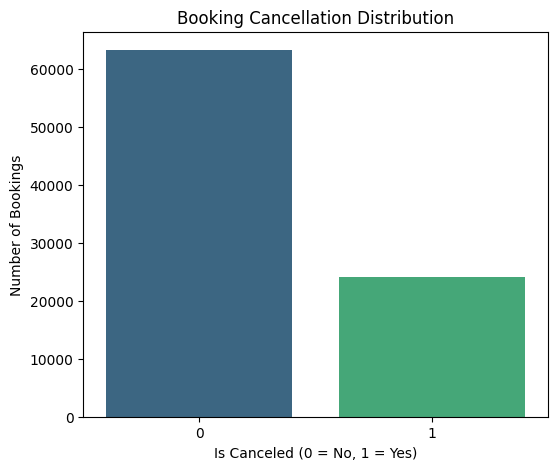

is_canceled
0    72.475897
1    27.524103
Name: proportion, dtype: float64


In [58]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='is_canceled', palette='viridis')
plt.title('Booking Cancellation Distribution')
plt.xlabel('Is Canceled (0 = No, 1 = Yes)')
plt.ylabel('Number of Bookings')
plt.show()

print(df['is_canceled'].value_counts(normalize=True) * 100)


## Cancellation Rate by Category
All the categorical/count "rate by X" comparisons are grouped into a single grid instead of one chart per cell, to keep this section compact.

/tmp/ipykernel_505/3733808002.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='is_canceled', order=order, palette='mako', errorbar=None, ax=ax)
/tmp/ipykernel_505/3733808002.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='is_canceled', order=order, palette='mako', errorbar=None, ax=ax)


/tmp/ipykernel_505/3733808002.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='is_canceled', order=order, palette='mako', errorbar=None, ax=ax)


/tmp/ipykernel_505/3733808002.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='is_canceled', order=order, palette='mako', errorbar=None, ax=ax)
/tmp/ipykernel_505/3733808002.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='is_canceled', order=order, palette='mako', errorbar=None, ax=ax)


/tmp/ipykernel_505/3733808002.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='is_canceled', order=order, palette='mako', errorbar=None, ax=ax)
/tmp/ipykernel_505/3733808002.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='is_canceled', order=order, palette='mako', errorbar=None, ax=ax)


/tmp/ipykernel_505/3733808002.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='is_canceled', order=order, palette='mako', errorbar=None, ax=ax)


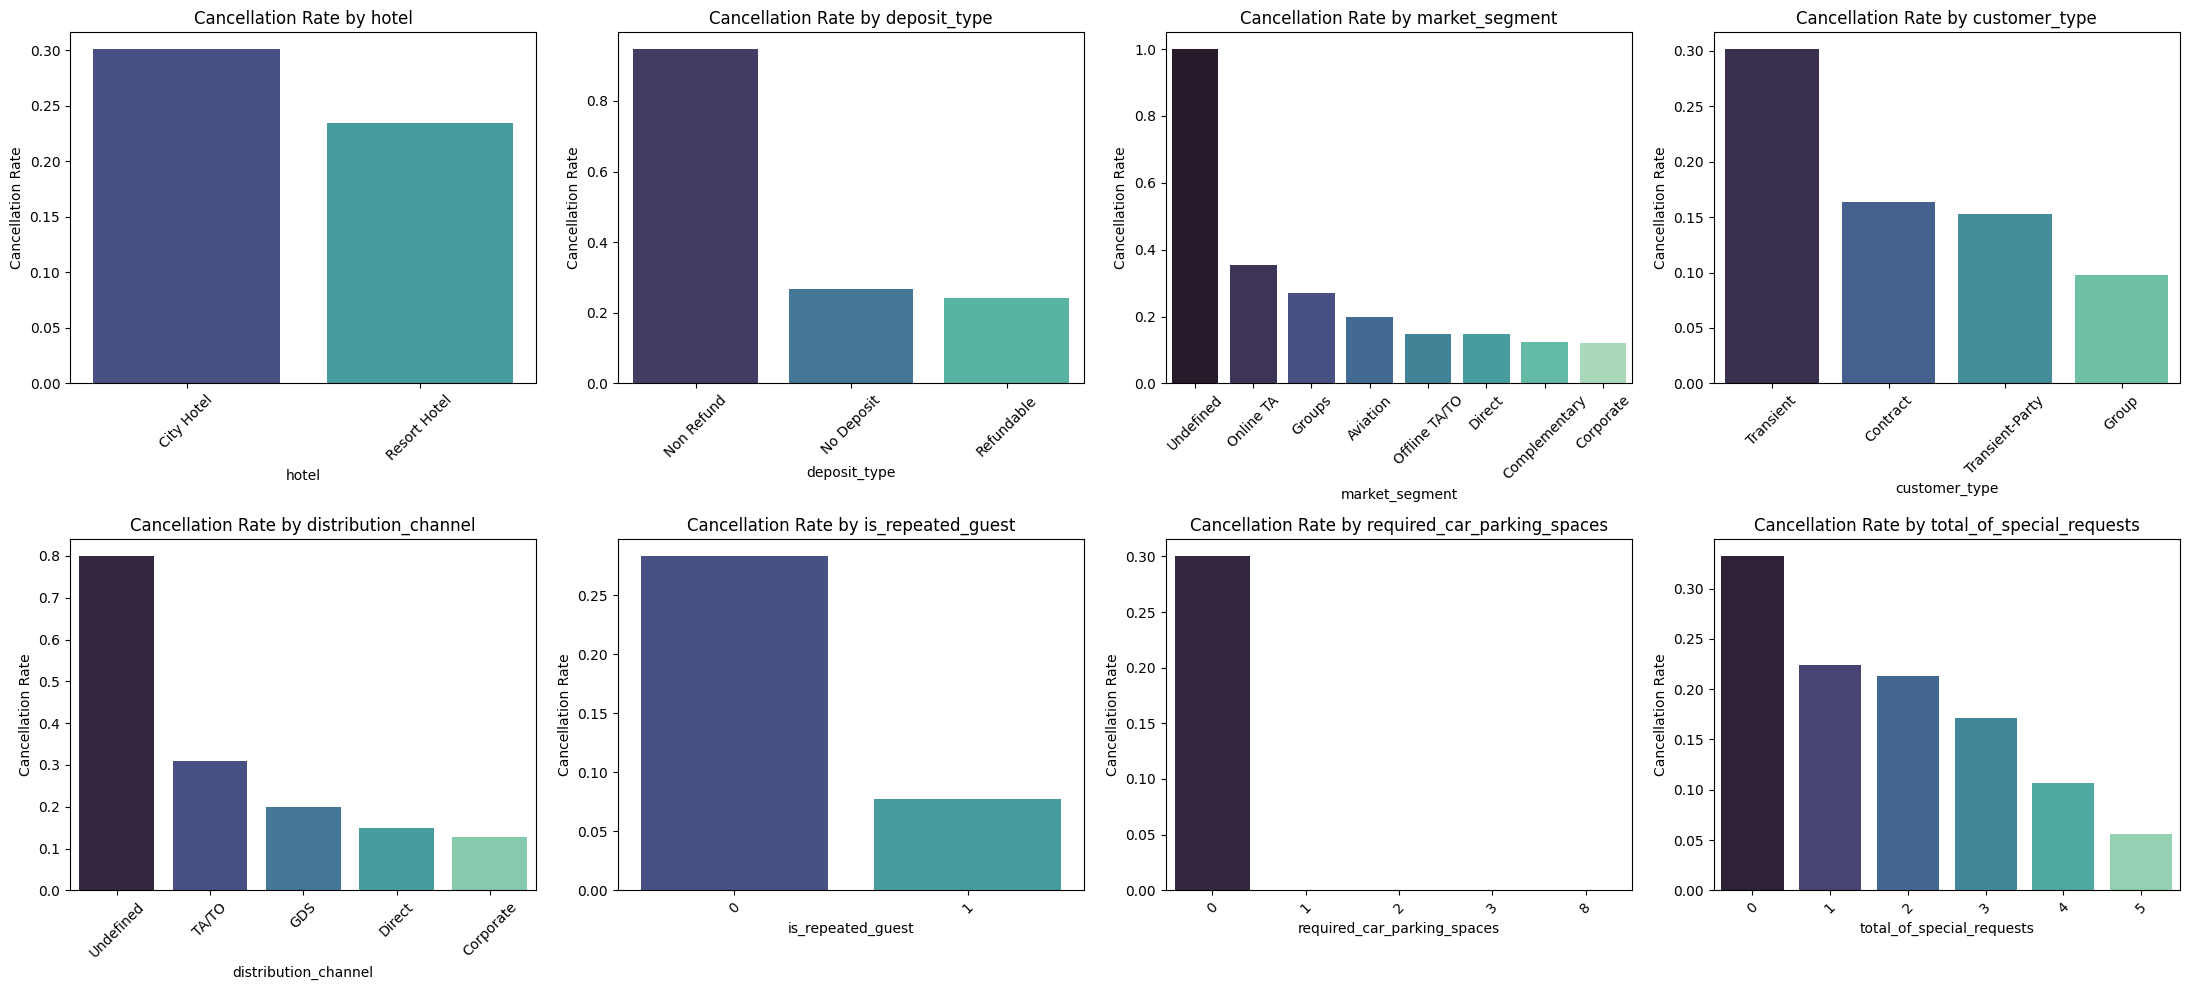

In [59]:
rate_by_columns = [
    'hotel',
    'deposit_type',
    'market_segment',
    'customer_type',
    'distribution_channel',
    'is_repeated_guest',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for ax, col in zip(axes, rate_by_columns):
    order = df.groupby(col)['is_canceled'].mean().sort_values(ascending=False).index
    sns.barplot(data=df, x=col, y='is_canceled', order=order, palette='mako', errorbar=None, ax=ax)
    ax.set_title(f'Cancellation Rate by {col}')
    ax.set_ylabel('Cancellation Rate')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Lead Time and ADR vs Cancellation

/tmp/ipykernel_505/2894137498.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_canceled', y='lead_time', palette='viridis', ax=axes[0])
/tmp/ipykernel_505/2894137498.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_canceled', y='adr', palette='viridis', ax=axes[1])


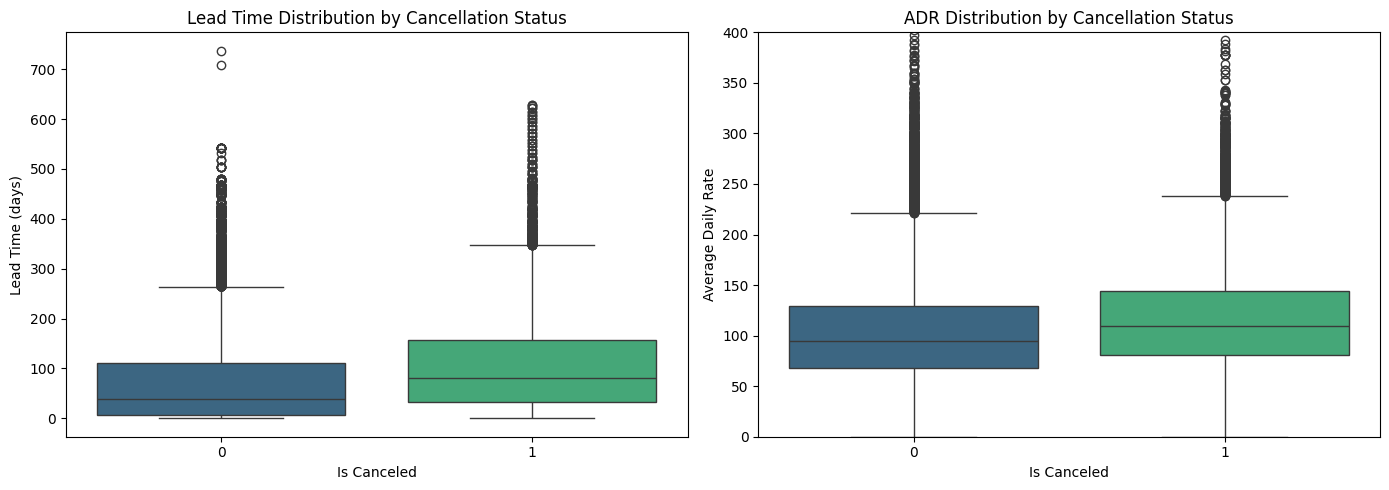

is_canceled
0     70.183581
1    105.738306
Name: lead_time, dtype: float64


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='is_canceled', y='lead_time', palette='viridis', ax=axes[0])
axes[0].set_title('Lead Time Distribution by Cancellation Status')
axes[0].set_xlabel('Is Canceled')
axes[0].set_ylabel('Lead Time (days)')

sns.boxplot(data=df, x='is_canceled', y='adr', palette='viridis', ax=axes[1])
axes[1].set_ylim(0, 400)
axes[1].set_title('ADR Distribution by Cancellation Status')
axes[1].set_xlabel('Is Canceled')
axes[1].set_ylabel('Average Daily Rate')

plt.tight_layout()
plt.show()

print(df.groupby('is_canceled')['lead_time'].mean())


## Booking Trends by Month

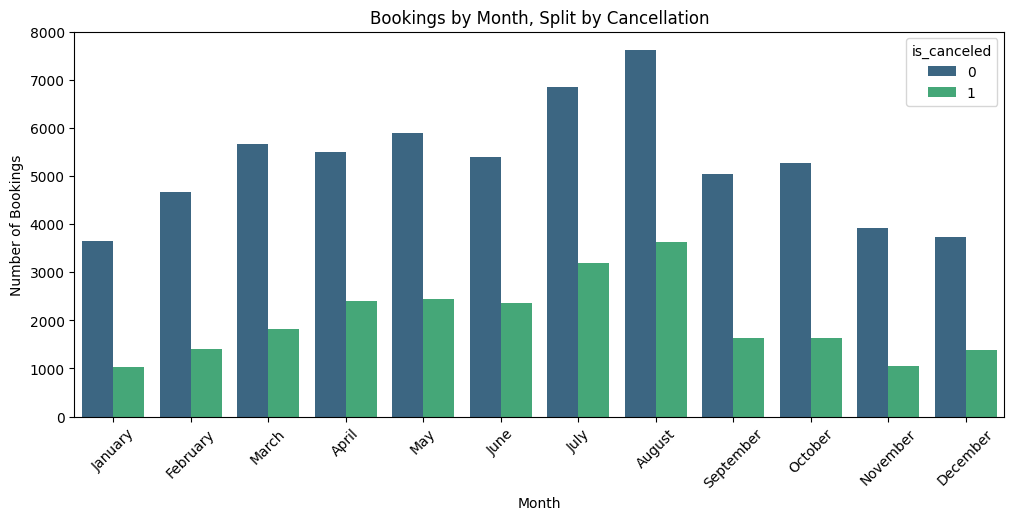

In [61]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='arrival_date_month', order=month_order, hue='is_canceled', palette='viridis')
plt.title('Bookings by Month, Split by Cancellation')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.show()


## Numeric Feature Distributions (Outlier-Prone Columns)

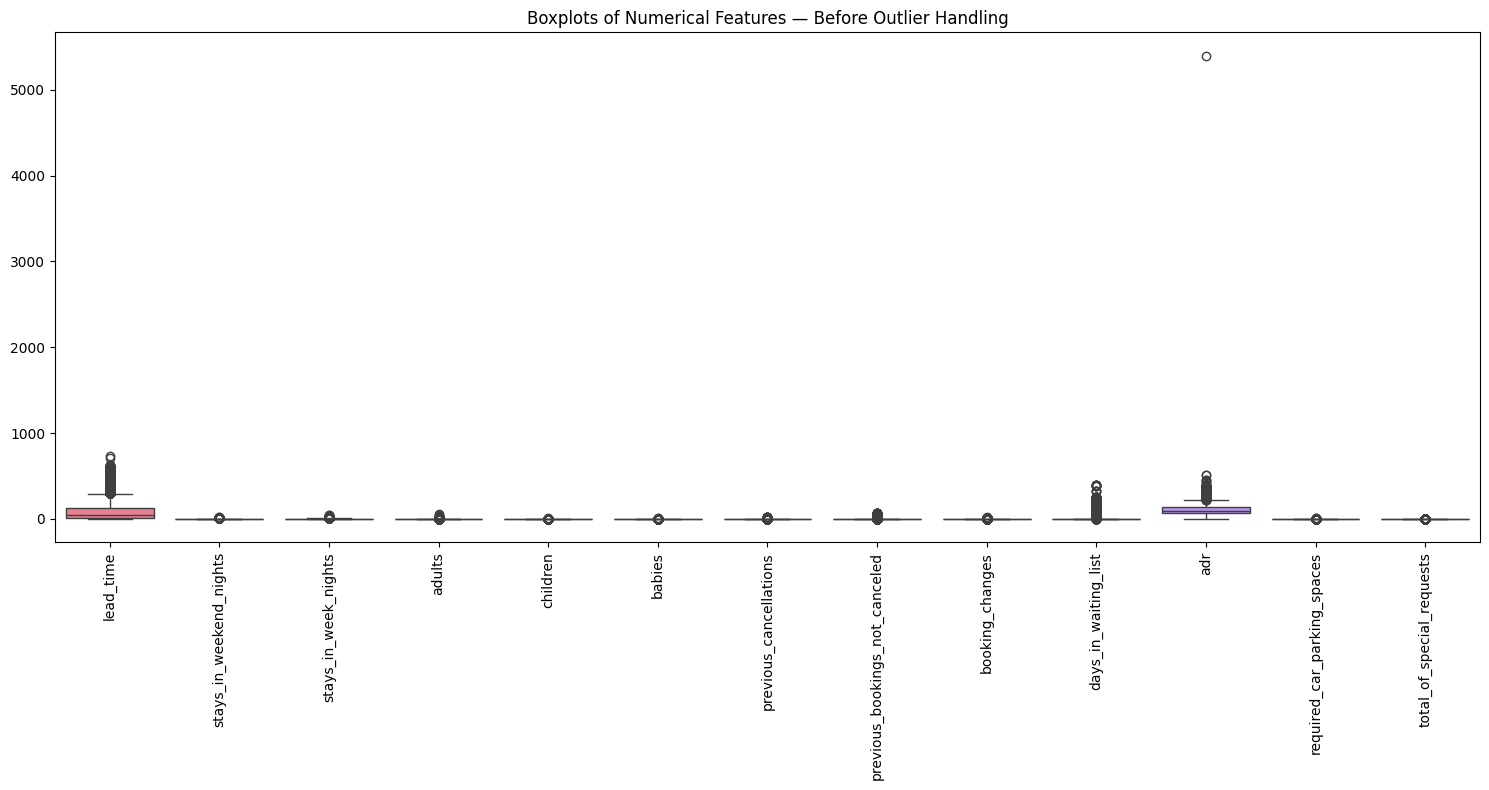

In [62]:
outlier_columns = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

plt.figure(figsize=(15, 8))
sns.boxplot(data=df[outlier_columns])
plt.xticks(rotation=90)
plt.title('Boxplots of Numerical Features — Before Outlier Handling')
plt.tight_layout()
plt.show()


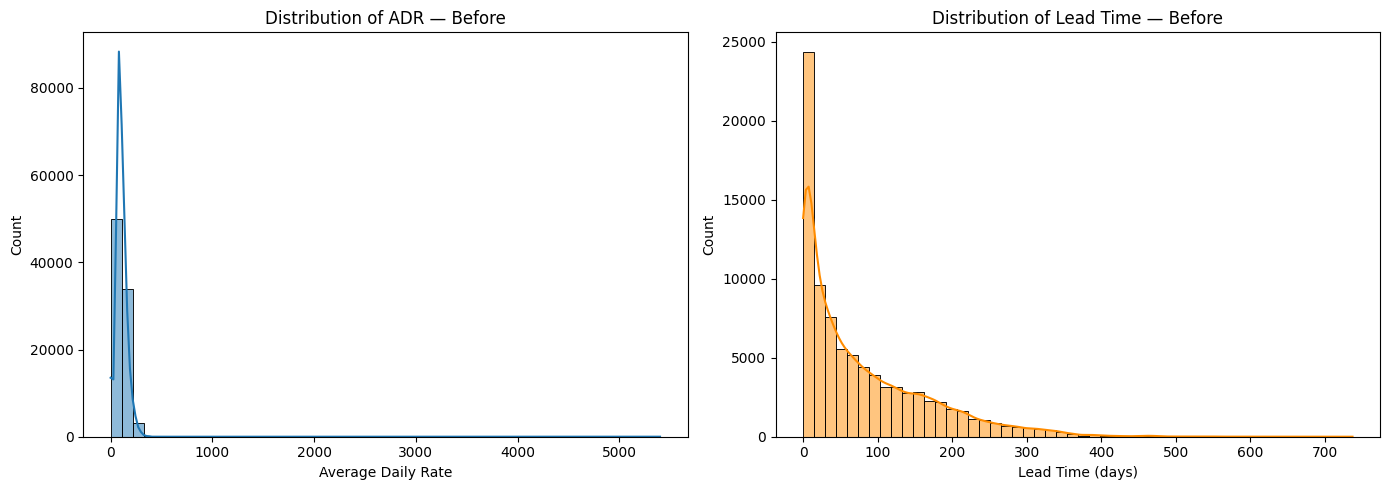

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['adr'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of ADR — Before')
axes[0].set_xlabel('Average Daily Rate')

sns.histplot(df['lead_time'], bins=50, kde=True, color='darkorange', ax=axes[1])
axes[1].set_title('Distribution of Lead Time — Before')
axes[1].set_xlabel('Lead Time (days)')

plt.tight_layout()
plt.show()


## Correlation Between Numerical Features

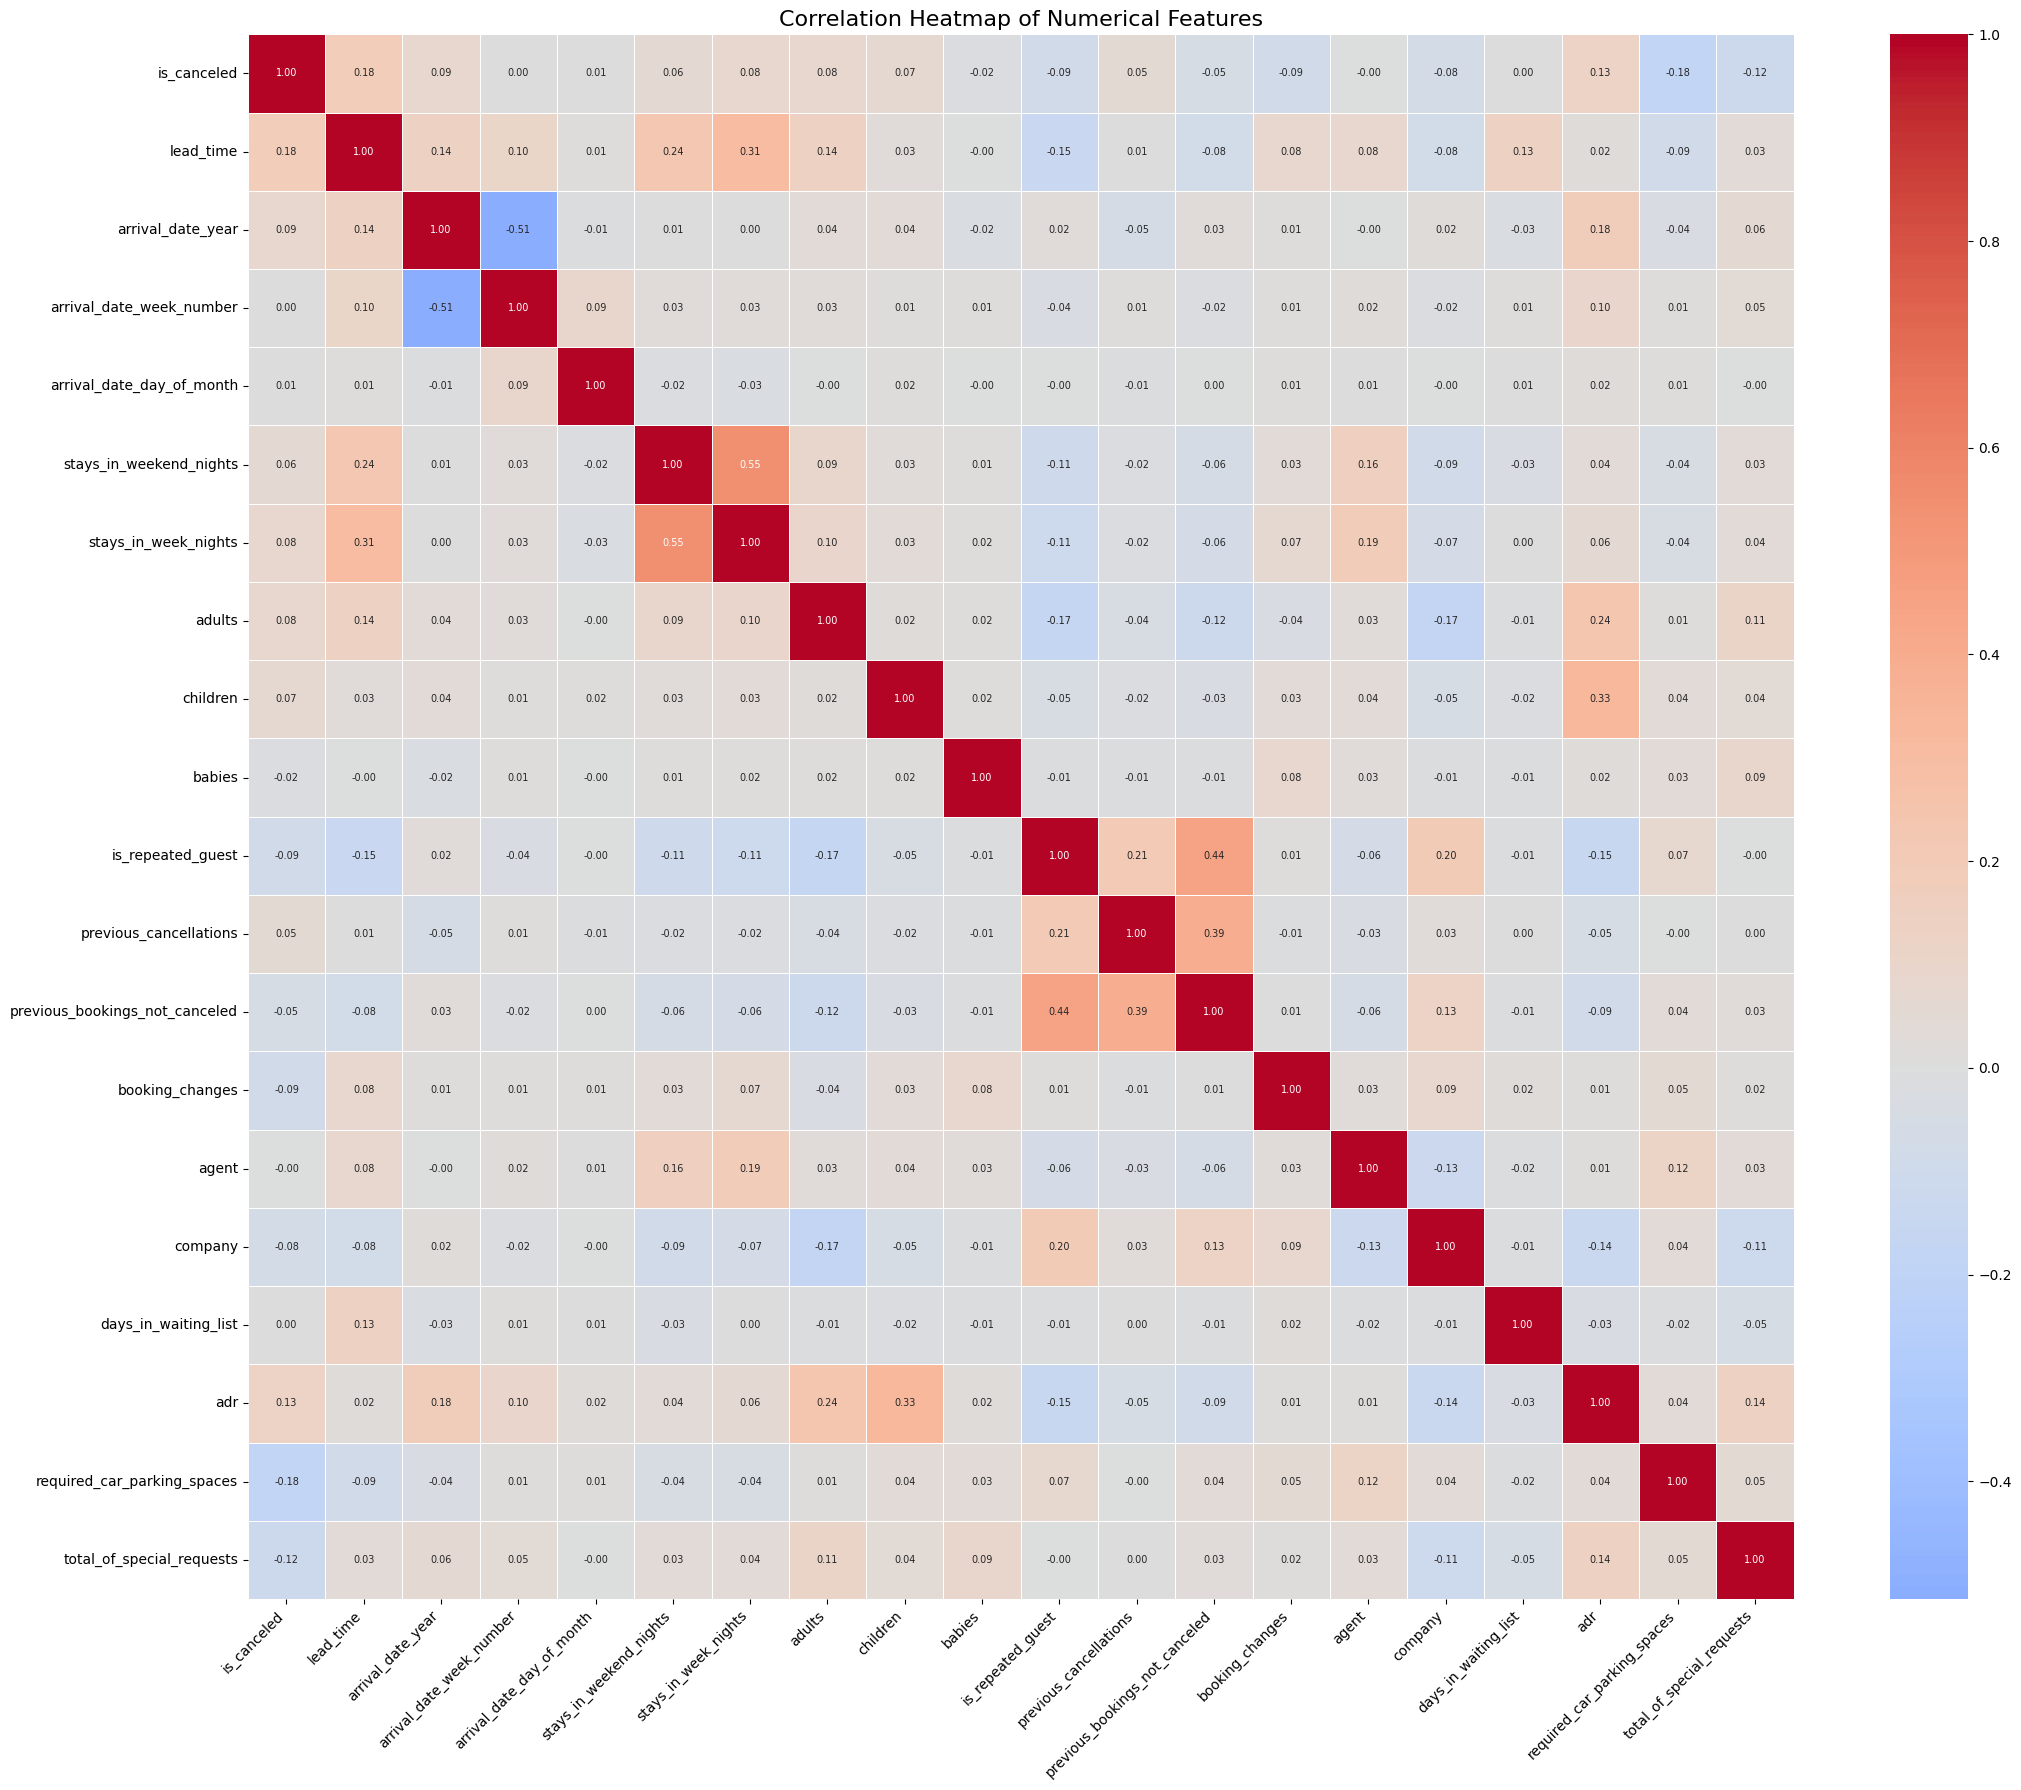

Top correlations with is_canceled:
is_canceled                       1.000000
lead_time                         0.184527
adr                               0.127221
arrival_date_year                 0.088029
stays_in_week_nights              0.084172
adults                            0.080272
children                          0.067180
stays_in_weekend_nights           0.061016
previous_cancellations            0.051500
arrival_date_day_of_month         0.005440
days_in_waiting_list              0.004710
arrival_date_week_number          0.001682
agent                            -0.001132
babies                           -0.020628
previous_bookings_not_canceled   -0.052171
company                          -0.075315
is_repeated_guest                -0.088741
booking_changes                  -0.093223
total_of_special_requests        -0.120800
required_car_parking_spaces      -0.184459
Name: is_canceled, dtype: float64


In [64]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(22, 18))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', annot_kws={'size': 7}, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Top correlations with is_canceled:")
print(corr['is_canceled'].sort_values(ascending=False))


## Additional Insights

/tmp/ipykernel_505/2425046680.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values, palette='mako', ax=axes[1])


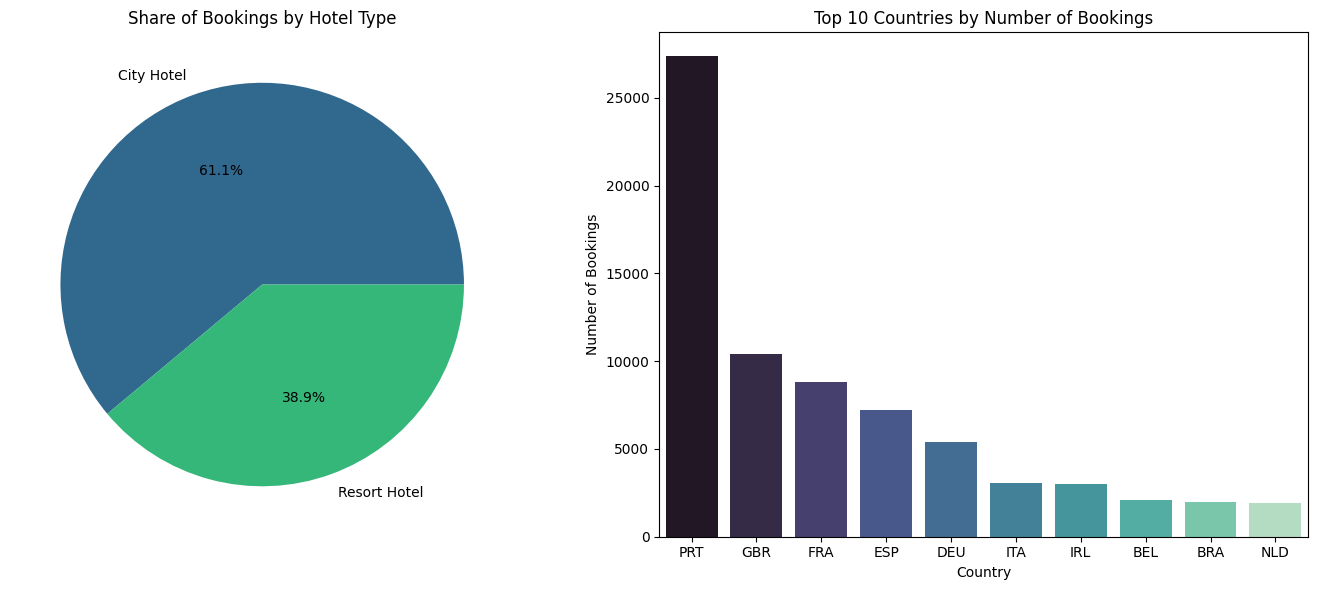

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df['hotel'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('viridis', 2), ax=axes[0])
axes[0].set_title('Share of Bookings by Hotel Type')
axes[0].set_ylabel('')

top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.index, y=top_countries.values, palette='mako', ax=axes[1])
axes[1].set_title('Top 10 Countries by Number of Bookings')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Number of Bookings')

plt.tight_layout()
plt.show()


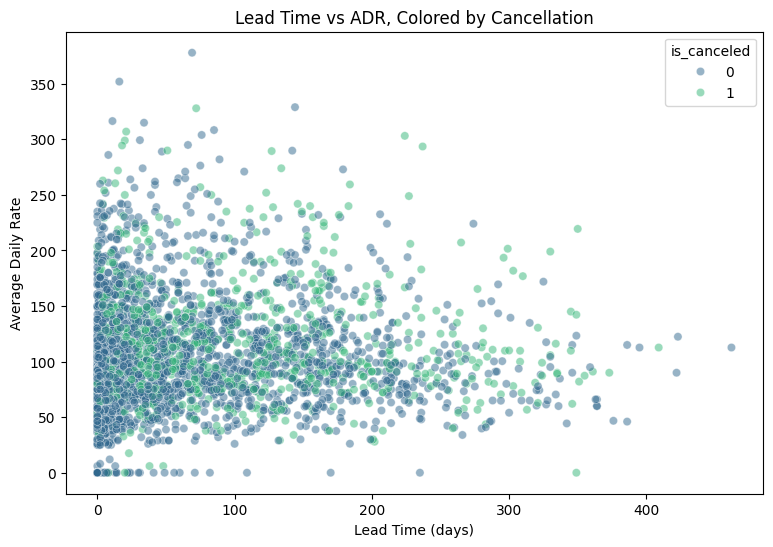

In [66]:
sample = df[(df['adr'] < 400) & (df['lead_time'] < 500)].sample(3000, random_state=42)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=sample, x='lead_time', y='adr', hue='is_canceled', alpha=0.5, palette='viridis')
plt.title('Lead Time vs ADR, Colored by Cancellation')
plt.xlabel('Lead Time (days)')
plt.ylabel('Average Daily Rate')
plt.show()


## EDA Summary — Before Outlier Handling

- The dataset is imbalanced: roughly 63% of bookings are not canceled vs 37% canceled.
- **Deposit type** shows a striking pattern: non-refundable bookings have a much higher cancellation rate than expected.
- **Lead time** is clearly higher on average for canceled bookings, and its distribution is heavily right-skewed with a long tail of extreme values.
- **ADR** is also right-skewed, with a small number of very high values pulling the distribution out.
- **Market segment**, **customer type**, and **distribution channel** all show meaningful variation in cancellation rate.
- **Repeated guests** cancel far less often than new guests, and more **special requests** is associated with a lower cancellation rate.
- The boxplots above confirm that `adr` and `lead_time` are the two columns most affected by extreme values — they are handled explicitly in the next section.

# Outlier Detection (IQR Method)

In [67]:
outlier_summary = []

for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    outlier_summary.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': outlier_count,
        'Outlier Percentage': outlier_count / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary.sort_values(by='Outlier Percentage', ascending=False).reset_index(drop=True)


,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,adults,2.00,2.0,0.00,2.000,2.000,22733,26.061287
1,booking_changes,0.00,0.0,0.00,0.000,0.000,15804,18.117828
2,children,0.00,0.0,0.00,0.000,0.000,8364,9.588554
3,required_car_parking_spaces,0.00,0.0,0.00,0.000,0.000,7306,8.375655
4,previous_bookings_not_canceled,0.00,0.0,0.00,0.000,0.000,3537,4.054844
5,total_of_special_requests,0.00,1.0,1.00,-1.500,2.500,2670,3.060909
6,adr,72.25,134.1,61.85,-20.525,226.875,2508,2.875191
7,lead_time,11.00,125.0,114.00,-160.000,296.000,2394,2.744500
8,previous_cancellations,0.00,0.0,0.00,0.000,0.000,1681,1.927111
9,stays_in_week_nights,1.00,4.0,3.00,-3.500,8.500,1514,1.735661


In [68]:
# Inspect the most extreme ADR and lead_time records to judge whether they are
# realistic booking behavior or data errors

display(df.nlargest(10, 'adr')[
    ['hotel', 'adr', 'adults', 'children', 'babies',
     'reserved_room_type', 'assigned_room_type', 'is_canceled']
])

display(df.nlargest(10, 'lead_time')[
    ['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month',
     'customer_type', 'market_segment', 'is_canceled']
])


,hotel,adr,adults,children,babies,reserved_room_type,assigned_room_type,is_canceled
48515,City Hotel,5400.00,2,0,0,A,A,1
111403,City Hotel,510.00,1,0,0,A,G,0
15083,Resort Hotel,508.00,2,0,0,A,C,0
103912,City Hotel,451.50,2,2,0,E,E,0
13142,Resort Hotel,450.00,2,0,0,A,A,1
13391,Resort Hotel,437.00,2,2,0,H,H,1
39155,Resort Hotel,426.25,2,2,0,G,G,0
39568,Resort Hotel,402.00,3,1,0,H,H,0
39118,Resort Hotel,397.38,3,2,0,H,H,0
13323,Resort Hotel,392.00,2,1,0,F,F,1


,hotel,lead_time,arrival_date_year,arrival_date_month,customer_type,market_segment,is_canceled
1,Resort Hotel,737,2015,July,Transient,Direct,0
4182,Resort Hotel,709,2016,February,Transient,Direct,0
65231,City Hotel,629,2017,March,Transient,Groups,1
65237,City Hotel,629,2017,March,Transient,Groups,1
60173,City Hotel,626,2016,November,Transient,Groups,1
65032,City Hotel,622,2017,March,Transient,Groups,1
65036,City Hotel,622,2017,March,Transient,Groups,1
64762,City Hotel,615,2017,March,Transient,Groups,1
64766,City Hotel,615,2017,March,Transient,Groups,1
64397,City Hotel,608,2017,March,Transient,Groups,1


# Outlier Handling

**Decision:** `adr` and `lead_time` are the two columns with the largest share of IQR outliers and the most extreme right-skew (see boxplots and summary table above). Their extreme values are realistic bookings rather than data-entry errors, so instead of deleting them, they are **capped (winsorized) at their IQR upper bound** — this tames the extreme tail without discarding any rows.

All other flagged columns (`previous_cancellations`, `booking_changes`, `days_in_waiting_list`, `babies`, etc.) are **left untouched**: they are naturally sparse, count-based features where a large value (e.g. many previous cancellations) is meaningful signal for predicting cancellation, not noise — capping them would remove exactly the pattern the model needs.

In [69]:
adr_upper = outlier_summary.loc[outlier_summary['Column'] == 'adr', 'Upper Bound'].values[0]
lead_time_upper = outlier_summary.loc[outlier_summary['Column'] == 'lead_time', 'Upper Bound'].values[0]

print(f"ADR upper cap: {adr_upper:.2f}  |  values above it: {(df['adr'] > adr_upper).sum()}")
print(f"Lead time upper cap: {lead_time_upper:.2f}  |  values above it: {(df['lead_time'] > lead_time_upper).sum()}")

print("\nBefore capping:")
print(df[['adr', 'lead_time']].describe())

df['adr'] = df['adr'].clip(upper=adr_upper)
df['lead_time'] = df['lead_time'].clip(upper=lead_time_upper)

print("\nAfter capping:")
print(df[['adr', 'lead_time']].describe())


ADR upper cap: 226.88  |  values above it: 2508
Lead time upper cap: 296.00  |  values above it: 2394

Before capping:
                adr     lead_time
count  87229.000000  87229.000000
mean     106.519325     79.969700
std       54.890211     86.058295
min        0.000000      0.000000
25%       72.250000     11.000000
50%       98.200000     49.000000
75%      134.100000    125.000000
max     5400.000000    737.000000

After capping:
                adr     lead_time
count  87229.000000  87229.000000
mean     105.521089     78.441459
std       49.034838     81.052235
min        0.000000      0.000000
25%       72.250000     11.000000
50%       98.200000     49.000000
75%      134.100000    125.000000
max      226.875000    296.000000


# Exploratory Data Analysis — After Outlier Handling

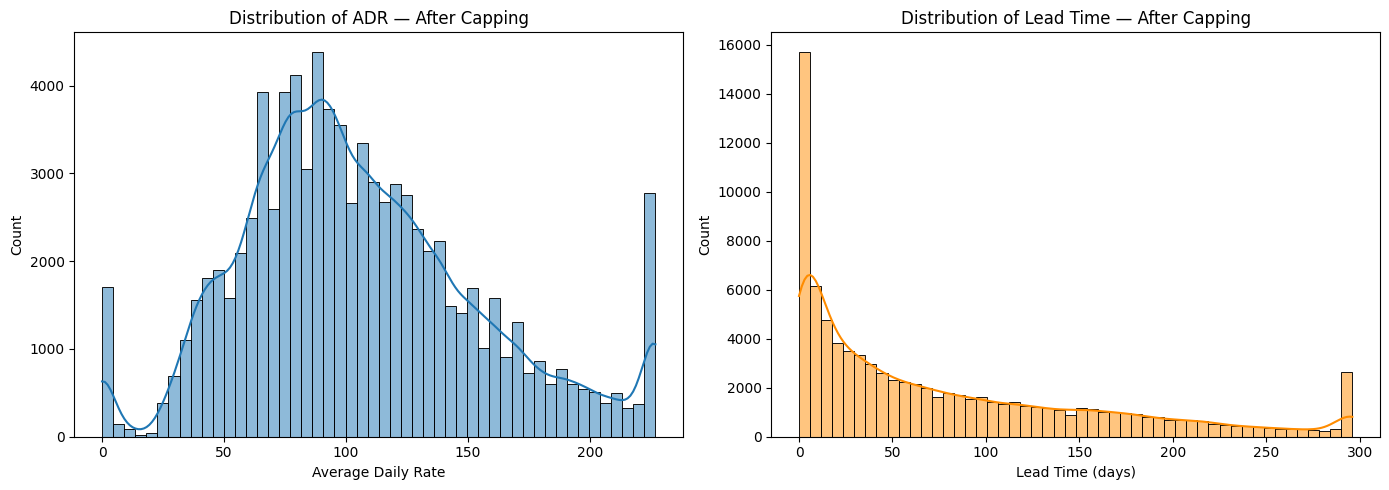

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['adr'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of ADR — After Capping')
axes[0].set_xlabel('Average Daily Rate')

sns.histplot(df['lead_time'], bins=50, kde=True, color='darkorange', ax=axes[1])
axes[1].set_title('Distribution of Lead Time — After Capping')
axes[1].set_xlabel('Lead Time (days)')

plt.tight_layout()
plt.show()


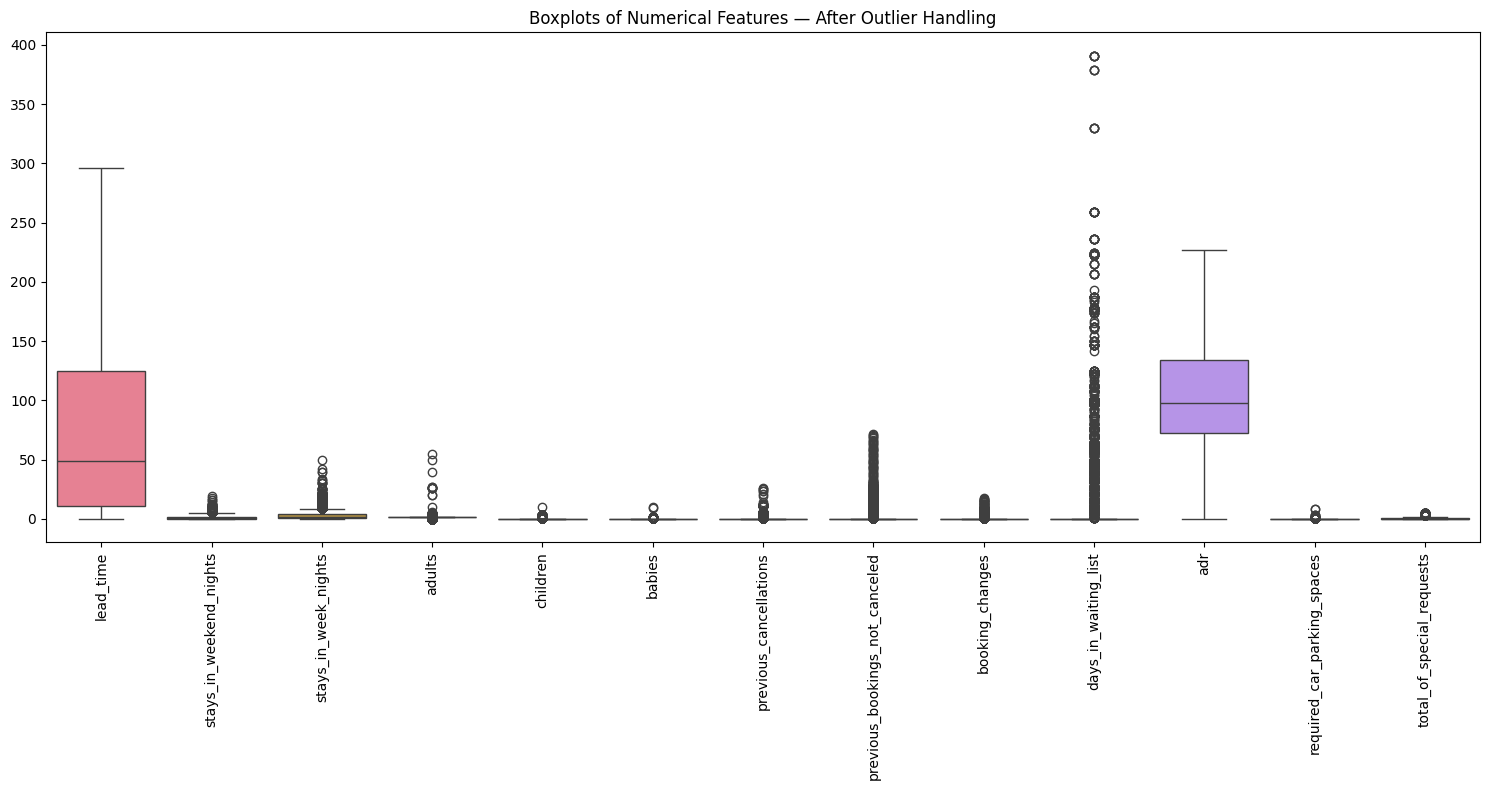

In [71]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[outlier_columns])
plt.xticks(rotation=90)
plt.title('Boxplots of Numerical Features — After Outlier Handling')
plt.tight_layout()
plt.show()


## EDA Summary — After Outlier Handling

- The extreme tails of `adr` and `lead_time` are gone; both distributions are now bounded at a realistic upper limit instead of stretching out toward rare, extreme values.
- The overall shape and relationships found in the "before" EDA (deposit type, market segment, lead time vs cancellation, etc.) are unchanged, since capping only affects a small number of extreme rows.
- All other count-based features were intentionally left as-is, since their extreme values carry predictive signal rather than noise.

# Feature Engineering

## Agent and Company Presence
Create binary flags instead of relying on the raw agent/company ID codes, since presence/absence of an agent or company is what carries signal (company presence is strongly correlated with lower cancellation rates).

In [72]:
# Create binary flags for whether a booking involved an agent or a company
df['has_agent'] = (df['agent'] != 0).astype(int)
df['has_company'] = (df['company'] != 0).astype(int)

print(df[['has_agent', 'has_company']].mean())

has_agent      0.860815
has_company    0.060037
dtype: float64


## Arrival Date Features
Combine the separate year/month/day columns into a single datetime, then extract day-of-week and weekend-arrival features that are not available from the split columns.

In [73]:
# Build a single arrival_date datetime column from the separate parts
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(str),
    format='%Y-%B-%d'
)

df['arrival_date'].head()

0   2015-07-01
1   2015-07-01
2   2015-07-01
3   2015-07-01
4   2015-07-01
Name: arrival_date, dtype: datetime64[us]

In [74]:
# Extract day of week / weekend arrival / quarter from arrival_date
df['arrival_day_of_week'] = df['arrival_date'].dt.dayofweek
df['is_weekend_arrival'] = df['arrival_day_of_week'].isin([5, 6]).astype(int)
df['arrival_quarter'] = df['arrival_date'].dt.quarter

df[['arrival_day_of_week', 'is_weekend_arrival', 'arrival_quarter']].head()

,arrival_day_of_week,is_weekend_arrival,arrival_quarter
0,2,0,3
1,2,0,3
2,2,0,3
3,2,0,3
4,2,0,3


In [75]:
# Convert the textual month name into a numeric month (needed since arrival_date_month is a string)
month_map = {m: i + 1 for i, m in enumerate([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])}

df['arrival_month_num'] = df['arrival_date_month'].map(month_map)

df[['arrival_date_month', 'arrival_month_num']].head()

,arrival_date_month,arrival_month_num
0,July,7
1,July,7
2,July,7
3,July,7
4,July,7


## Room Mismatch and Total Nights
These were already created during EDA (cells above) — kept here as part of the feature set used for modeling.

In [76]:
# Already created in EDA, confirming they are present for modeling
df['room_mismatch'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

df[['room_mismatch', 'total_nights']].head()

,room_mismatch,total_nights
0,0,0
1,0,0
2,1,1
3,0,1
4,0,2


## Drop Columns No Longer Needed
Drop columns that either leak the target (`reservation_status`, `reservation_status_date`) or have been superseded by engineered features (`arrival_date`, `arrival_date_month`, raw `agent`/`company` IDs).

In [77]:
columns_to_drop = [
    'reservation_status',
    'reservation_status_date',
    'arrival_date',
    'arrival_date_month',
    'agent',
    'company'
]

df = df.drop(columns=columns_to_drop)

print(df.shape)

(87229, 35)


# Encoding

## One-Hot Encoding for Low-Cardinality Categorical Columns
These columns have a small number of unrelated categories, so one-hot encoding avoids implying a false order between them.

In [78]:
low_card_cols = [
    'hotel',
    'meal',
    'market_segment',
    'distribution_channel',
    'deposit_type',
    'customer_type',
    'reserved_room_type',
    'assigned_room_type'
]

df = pd.get_dummies(df, columns=low_card_cols, drop_first=True)

print(df.shape)

(87229, 66)


In [79]:
country_freq = df['country'].value_counts()
df['country_encoded'] = df['country'].map(country_freq)
df = df.drop(columns=['country'])

In [80]:
df.shape

(87229, 66)

In [81]:
numeric_cols = df.select_dtypes(include=['int64', 'float64', 'bool']).columns

corr = df[numeric_cols].corr()
target_corr = corr['is_canceled'].sort_values(ascending=False)

print("Top positive correlations with is_canceled:")
print(target_corr.head(15))

print("\nTop negative correlations with is_canceled:")
print(target_corr.tail(15))

Top positive correlations with is_canceled:
is_canceled                   1.000000
market_segment_Online TA      0.211570
lead_time                     0.188382
deposit_type_Non Refund       0.165058
distribution_channel_TA/TO    0.151641
adr                           0.136546
has_agent                     0.133010
customer_type_Transient       0.126776
country_encoded               0.101867
arrival_date_year             0.088029
total_nights                  0.085450
stays_in_week_nights          0.084172
adults                        0.080272
children                      0.067180
meal_SC                       0.062210
Name: is_canceled, dtype: float64

Top negative correlations with is_canceled:
assigned_room_type_I             -0.037261
assigned_room_type_D             -0.043444
previous_bookings_not_canceled   -0.052171
hotel_Resort Hotel               -0.072216
market_segment_Corporate         -0.077575
is_repeated_guest                -0.088741
booking_changes                  -

# Feature Selection

## Prepare X and y

In [82]:
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (87229, 65)
y shape: (87229,)


## Remove Low-Variance Features
Drop columns that are almost constant (e.g. a rare one-hot category present in <1% of rows) since they carry very little signal.

In [83]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
selector.fit(X)

low_variance_cols = X.columns[~selector.get_support()].tolist()
print(f'Dropping {len(low_variance_cols)} low-variance columns:')
print(low_variance_cols)

X = X.drop(columns=low_variance_cols)
print('\nX shape after variance filtering:', X.shape)

Dropping 14 low-variance columns:
['meal_FB', 'meal_Undefined', 'market_segment_Complementary', 'market_segment_Undefined', 'distribution_channel_GDS', 'distribution_channel_Undefined', 'deposit_type_Refundable', 'customer_type_Group', 'reserved_room_type_H', 'reserved_room_type_L', 'assigned_room_type_H', 'assigned_room_type_I', 'assigned_room_type_K', 'assigned_room_type_L']

X shape after variance filtering: (87229, 51)


## Feature Importance via Random Forest
Fit a quick Random Forest on all remaining features to rank them by importance. This is only used to guide feature selection, not as a final model.

/tmp/ipykernel_505/2742642551.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.head(20).values, y=importances.head(20).index, palette='mako')


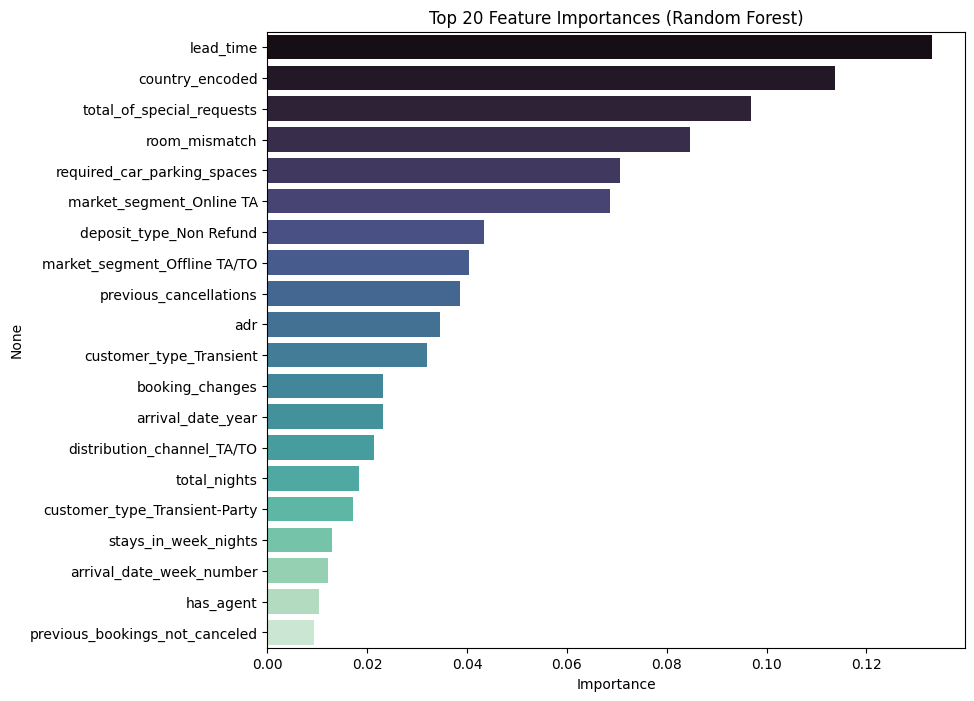

In [84]:
from sklearn.ensemble import RandomForestClassifier

rf_selector = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf_selector.fit(X, y)

importances = pd.Series(rf_selector.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 8))
sns.barplot(x=importances.head(20).values, y=importances.head(20).index, palette='mako')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.show()

## Select Top Features
Keep the smallest set of features that together explain 95% of the cumulative importance. This drops long-tail features (mostly rare one-hot categories) that add noise without much predictive value.

In [85]:
cumulative_importance = importances.cumsum()
n_features = (cumulative_importance <= 0.95).sum() + 1
selected_features = importances.head(n_features).index.tolist()

print(f'Selected {len(selected_features)} out of {X.shape[1]} features (95% cumulative importance)')
print(selected_features)

X = X[selected_features]

Selected 27 out of 51 features (95% cumulative importance)
['lead_time', 'country_encoded', 'total_of_special_requests', 'room_mismatch', 'required_car_parking_spaces', 'market_segment_Online TA', 'deposit_type_Non Refund', 'market_segment_Offline TA/TO', 'previous_cancellations', 'adr', 'customer_type_Transient', 'booking_changes', 'arrival_date_year', 'distribution_channel_TA/TO', 'total_nights', 'customer_type_Transient-Party', 'stays_in_week_nights', 'arrival_date_week_number', 'has_agent', 'previous_bookings_not_canceled', 'arrival_date_day_of_month', 'arrival_month_num', 'market_segment_Direct', 'hotel_Resort Hotel', 'stays_in_weekend_nights', 'distribution_channel_Direct', 'adults']


# Train/Test Split

In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('\nTrain cancellation rate:', y_train.mean().round(3))
print('Test cancellation rate:', y_test.mean().round(3))

Train shape: (69783, 27)
Test shape: (17446, 27)

Train cancellation rate: 0.275
Test cancellation rate: 0.275


## Feature Scaling
Logistic Regression and KNN are distance/gradient based and need scaled features. Tree-based models (Decision Tree, Random Forest, Gradient Boosting, XGBoost) are scale-invariant, so they use the unscaled data.

In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training and Evaluation

## Evaluation Helper
A shared function so every model is scored the same way. Accuracy alone is misleading here since the target is imbalanced (~63/37), so precision, recall, F1, and ROC-AUC are tracked too.

In [88]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

results = []
trained_models = {}
test_predictions = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)

    y_pred_train = model.predict(X_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    train_accuracy = accuracy_score(y_tr, y_pred_train)
    test_accuracy = accuracy_score(y_te, y_pred)

    metrics = {
        'Model': name,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy,
        'Accuracy Gap': train_accuracy - test_accuracy,
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1 Score': f1_score(y_te, y_pred),
        'ROC-AUC': roc_auc_score(y_te, y_proba)
    }

    results.append(metrics)
    trained_models[name] = model
    test_predictions[name] = y_pred

    print(f'--- {name} ---')
    print(f'Train Accuracy: {train_accuracy:.4f} | Test Accuracy: {test_accuracy:.4f} | Gap: {train_accuracy - test_accuracy:.4f}')
    print(classification_report(y_te, y_pred, target_names=['Not Canceled', 'Canceled']))

    return metrics

## Model 1: Logistic Regression

In [89]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
_ = evaluate_model('Logistic Regression', log_reg, X_train_scaled, X_test_scaled, y_train, y_test)

--- Logistic Regression ---
Train Accuracy: 0.7849 | Test Accuracy: 0.7893 | Gap: -0.0045
              precision    recall  f1-score   support

Not Canceled       0.82      0.91      0.86     12644
    Canceled       0.67      0.46      0.55      4802

    accuracy                           0.79     17446
   macro avg       0.74      0.69      0.70     17446
weighted avg       0.78      0.79      0.78     17446



## Model 2: Decision Tree

In [90]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=12, random_state=42)
_ = evaluate_model('Decision Tree', dt, X_train, X_test, y_train, y_test)

--- Decision Tree ---
Train Accuracy: 0.8363 | Test Accuracy: 0.8243 | Gap: 0.0119
              precision    recall  f1-score   support

Not Canceled       0.87      0.89      0.88     12644
    Canceled       0.70      0.64      0.67      4802

    accuracy                           0.82     17446
   macro avg       0.78      0.77      0.77     17446
weighted avg       0.82      0.82      0.82     17446



## Model 3: Random Forest

In [91]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=1,
    max_features='sqrt',
    criterion='entropy',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
_ = evaluate_model('Random Forest', rf, X_train, X_test, y_train, y_test)

--- Random Forest ---
Train Accuracy: 0.9973 | Test Accuracy: 0.8501 | Gap: 0.1472
              precision    recall  f1-score   support

Not Canceled       0.88      0.92      0.90     12644
    Canceled       0.76      0.66      0.71      4802

    accuracy                           0.85     17446
   macro avg       0.82      0.79      0.80     17446
weighted avg       0.85      0.85      0.85     17446



## Model 4: Gradient Boosting

In [92]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=150, max_depth=4, learning_rate=0.1, random_state=42)
_ = evaluate_model('Gradient Boosting', gb, X_train, X_test, y_train, y_test)

--- Gradient Boosting ---
Train Accuracy: 0.8369 | Test Accuracy: 0.8380 | Gap: -0.0011
              precision    recall  f1-score   support

Not Canceled       0.87      0.91      0.89     12644
    Canceled       0.74      0.64      0.68      4802

    accuracy                           0.84     17446
   macro avg       0.80      0.78      0.79     17446
weighted avg       0.83      0.84      0.83     17446



## Model 5: K-Nearest Neighbors

In [93]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
_ = evaluate_model('KNN', knn, X_train_scaled, X_test_scaled, y_train, y_test)

--- KNN ---
Train Accuracy: 0.8394 | Test Accuracy: 0.8198 | Gap: 0.0196
              precision    recall  f1-score   support

Not Canceled       0.86      0.90      0.88     12644
    Canceled       0.70      0.60      0.65      4802

    accuracy                           0.82     17446
   macro avg       0.78      0.75      0.76     17446
weighted avg       0.81      0.82      0.82     17446



## Model 6: XGBoost
Requires the `xgboost` package (`pip install xgboost`) if not already installed.

In [94]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=42, eval_metric='logloss', n_jobs=-1
)
_ = evaluate_model('XGBoost', xgb, X_train, X_test, y_train, y_test)

--- XGBoost ---
Train Accuracy: 0.8562 | Test Accuracy: 0.8451 | Gap: 0.0111
              precision    recall  f1-score   support

Not Canceled       0.88      0.91      0.90     12644
    Canceled       0.75      0.66      0.70      4802

    accuracy                           0.85     17446
   macro avg       0.81      0.79      0.80     17446
weighted avg       0.84      0.85      0.84     17446



## Model 7: Linear Regression
Linear Regression is built for continuous targets, not classification, so it's not a natural fit here — Logistic Regression is the standard linear baseline for this task. It's included anyway for comparison: its raw output is thresholded at 0.5 to produce class labels.

In [95]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_raw_train_lr = lin_reg.predict(X_train_scaled)
y_raw_lr = lin_reg.predict(X_test_scaled)
y_proba_lr = np.clip(y_raw_lr, 0, 1)

y_pred_train_lr = (y_raw_train_lr >= 0.5).astype(int)
y_pred_lr = (y_raw_lr >= 0.5).astype(int)

train_accuracy_lr = accuracy_score(y_train, y_pred_train_lr)
test_accuracy_lr = accuracy_score(y_test, y_pred_lr)

metrics = {
    'Model': 'Linear Regression',
    'Train Accuracy': train_accuracy_lr,
    'Test Accuracy': test_accuracy_lr,
    'Accuracy Gap': train_accuracy_lr - test_accuracy_lr,
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1 Score': f1_score(y_test, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_test, y_proba_lr)
}

results.append(metrics)
trained_models['Linear Regression'] = lin_reg
test_predictions['Linear Regression'] = y_pred_lr

print('--- Linear Regression ---')
print(f'Train Accuracy: {train_accuracy_lr:.4f} | Test Accuracy: {test_accuracy_lr:.4f} | Gap: {train_accuracy_lr - test_accuracy_lr:.4f}')
print(classification_report(y_test, y_pred_lr, target_names=['Not Canceled', 'Canceled']))

--- Linear Regression ---
Train Accuracy: 0.7781 | Test Accuracy: 0.7840 | Gap: -0.0059
              precision    recall  f1-score   support

Not Canceled       0.80      0.94      0.86     12644
    Canceled       0.71      0.36      0.48      4802

    accuracy                           0.78     17446
   macro avg       0.75      0.65      0.67     17446
weighted avg       0.77      0.78      0.76     17446



## Model Comparison

In [96]:
results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False).reset_index(drop=True)
results_df

,Model,Train Accuracy,Test Accuracy,Accuracy Gap,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.997306,0.850109,0.147197,0.762545,0.661391,0.708375,0.911529
1,XGBoost,0.856168,0.845065,0.011104,0.745727,0.663265,0.702083,0.907568
2,Gradient Boosting,0.836880,0.837957,-0.001077,0.738931,0.635985,0.683604,0.898927
3,Decision Tree,0.836264,0.824315,0.011949,0.697342,0.639109,0.666956,0.879744
4,KNN,0.839402,0.819844,0.019558,0.702465,0.599334,0.646814,0.875554
5,Logistic Regression,0.784876,0.789350,-0.004474,0.670706,0.461058,0.546464,0.838627
6,Linear Regression,0.778098,0.783962,-0.005864,0.711420,0.361933,0.479779,0.827679


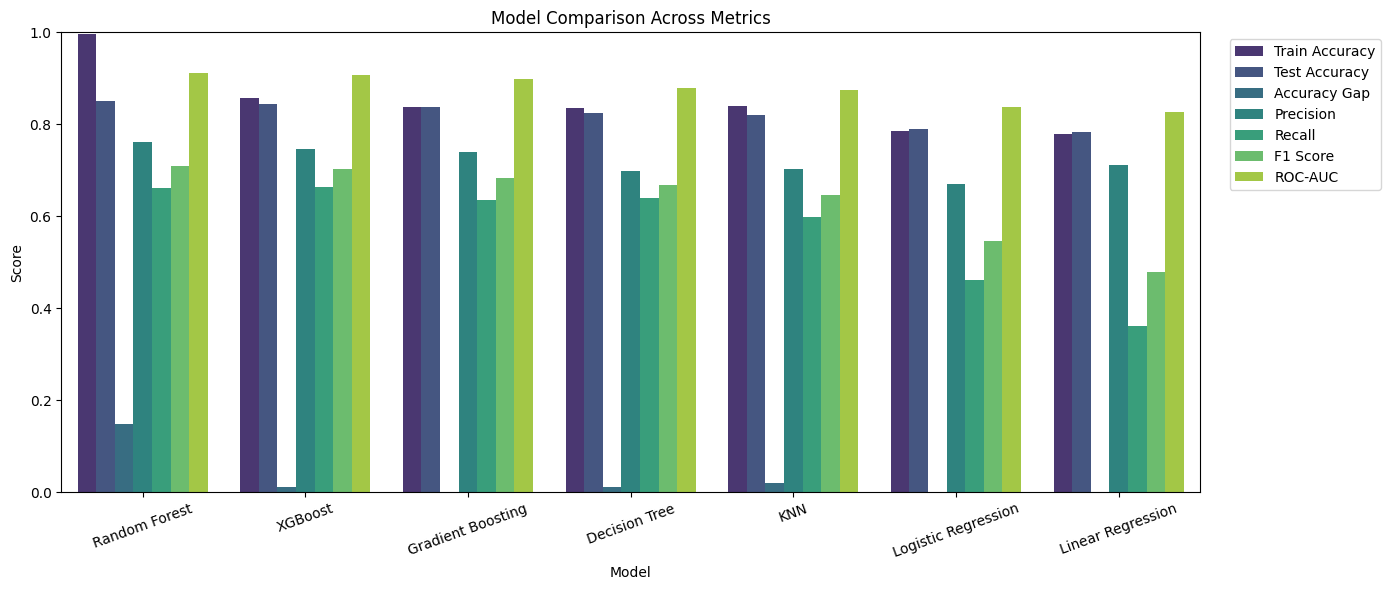

In [97]:
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('Model Comparison Across Metrics')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Train vs Test Accuracy (Overfitting Check)
Comparing accuracy on the training set vs the test set for each model. A large gap (train much higher than test) signals overfitting.

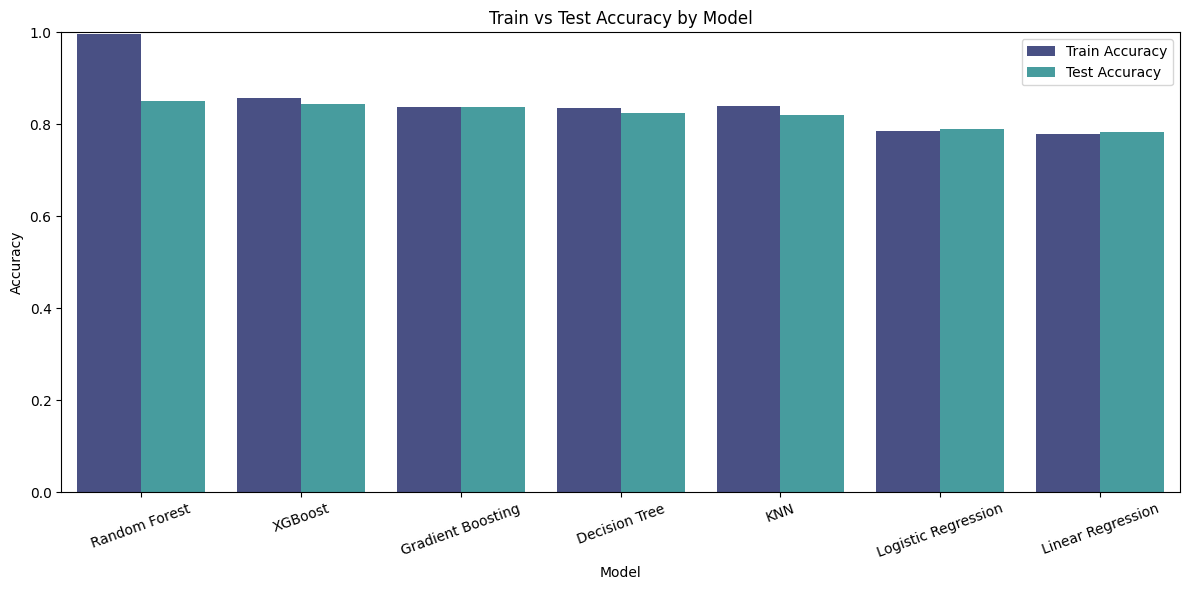

,Model,Train Accuracy,Test Accuracy,Accuracy Gap
0,Random Forest,0.997306,0.850109,0.147197
4,KNN,0.839402,0.819844,0.019558
3,Decision Tree,0.836264,0.824315,0.011949
1,XGBoost,0.856168,0.845065,0.011104
2,Gradient Boosting,0.836880,0.837957,-0.001077
5,Logistic Regression,0.784876,0.789350,-0.004474
6,Linear Regression,0.778098,0.783962,-0.005864


In [98]:
accuracy_compare = results_df[['Model', 'Train Accuracy', 'Test Accuracy']].melt(
    id_vars='Model', var_name='Split', value_name='Accuracy'
)

plt.figure(figsize=(12, 6))
sns.barplot(data=accuracy_compare, x='Model', y='Accuracy', hue='Split', palette='mako')
plt.title('Train vs Test Accuracy by Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(title='')
plt.tight_layout()
plt.show()

results_df[['Model', 'Train Accuracy', 'Test Accuracy', 'Accuracy Gap']].sort_values('Accuracy Gap', ascending=False)

## Confusion Matrices

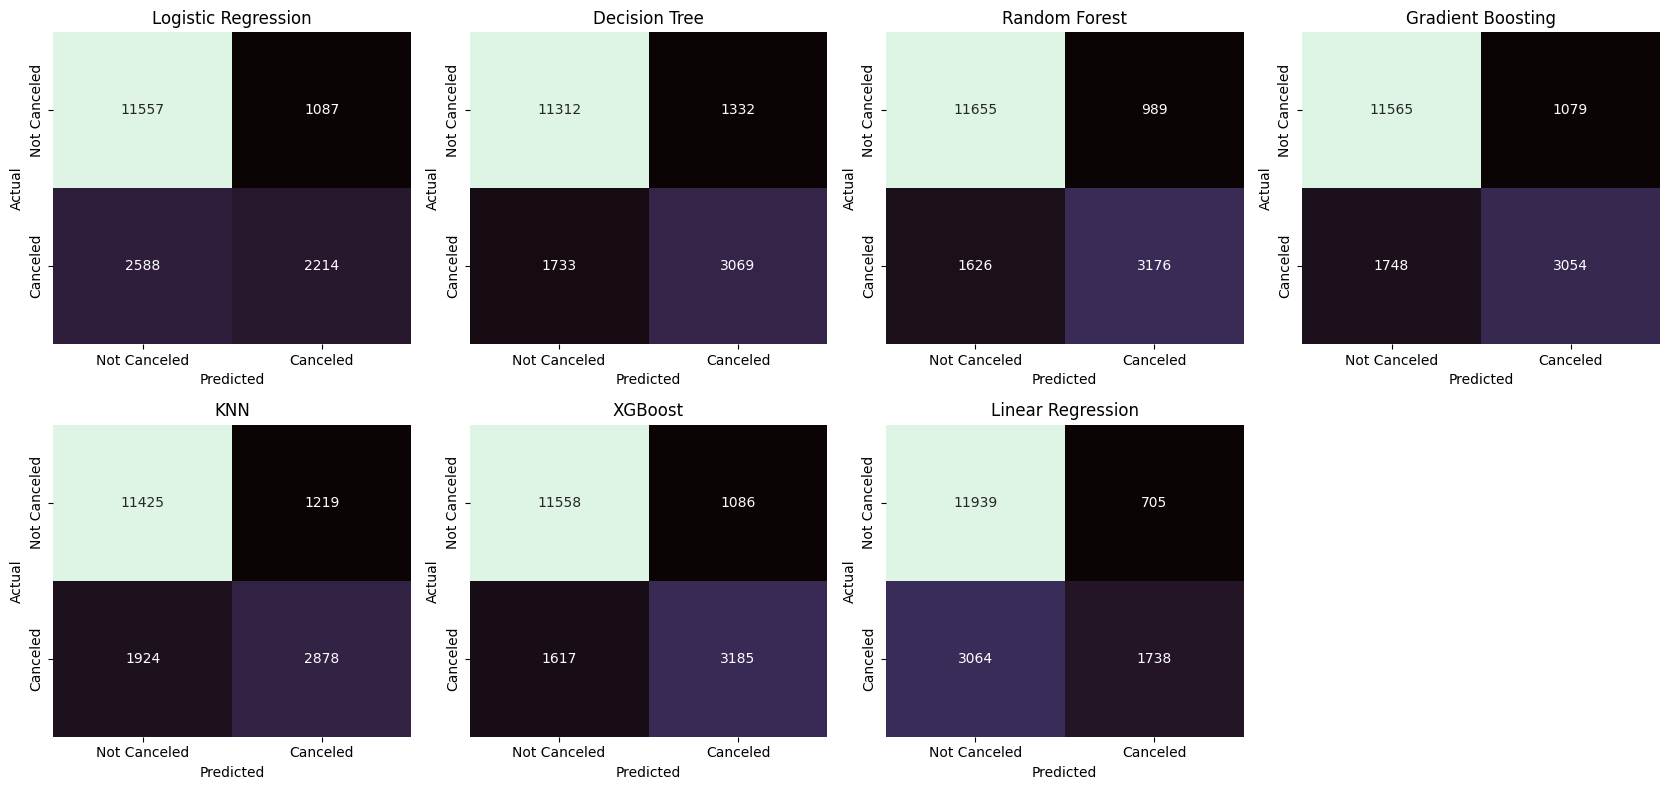

In [99]:
import math

n_models = len(test_predictions)
n_cols = 4
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, test_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='mako', cbar=False, ax=ax,
                xticklabels=['Not Canceled', 'Canceled'],
                yticklabels=['Not Canceled', 'Canceled'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# Hide any unused subplot slots
for ax in axes[n_models:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Modeling Summary

- Ranked by **F1 Score** (better fit than accuracy alone for this imbalanced target).
- Tree-based ensembles (Random Forest, Gradient Boosting, XGBoost) are expected to outperform Logistic Regression and KNN here, since the target has non-linear relationships with features like `lead_time`, `deposit_type_Non Refund`, and `room_mismatch`.
- Check the table above for the actual ranking and pick the best model based on which metric matters most for the business case — e.g. **Recall** if missing an actual cancellation is costlier, or **Precision** if false alarms are costlier.